<a href="https://colab.research.google.com/github/qositok565/Praktikum_AI_Tugas_ANN/blob/main/Klasifikasi_Kategori_Smartphone_menggunakan_Artificial_Neural_Networks_(ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Klasifikasi Kategori Smartphone menggunakan Artificial Neural Networks (ANN)**

Jaringan Saraf Buatan ( Artificial Neural Networks / ANN) adalah salah satu arsitektur dasar dalam pembelajaran mendalam ( deep learning ) yang terinspirasi oleh cara kerja jaringan saraf biologi manusia. Jaringan ini umumnya terdiri dari:

* Lapisan Masukan (Input Layer): Menerima fitur-fitur dari data. Dalam studi kasus ini, kami menggunakan spesifikasi smartphone: Spec Score , RAM , dan Kapasitas Baterai.

* Lapisan Tersembunyi (Hidden Layer): Memproses informasi melalui kombinasi bobot, bias, dan fungsi aktivasi.

* Lapisan Keluaran (Output Layer): Menghasilkan prediksi akhir (apakah smartphone termasuk kategori Flagship atau Bukan ).

* Bobot (Weights) dan Bias: Parameter yang disesuaikan selama proses pelatihan agar model dapat belajar.

* Fungsi Aktivasi: Memasukkan sifat non-linear ke dalam jaringan sehingga model dapat mempelajari pola yang rumit.

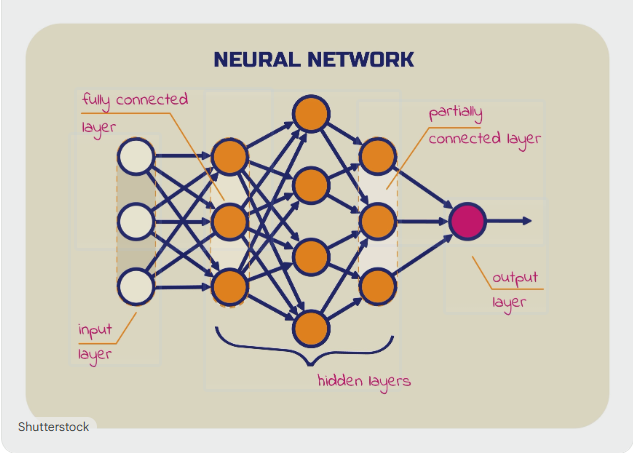

*Arsitektur Umum Jaringan Saraf Buatan (ANN) dengan Alur Perambatan Maju (Forward Propagation) dari Input Layer hingga Output Layer.*

**Langkah-langkah Penyelesaian Studi Kasus :**

**Langkah 1: Mengimpor Pustaka dan Menyiapkan Data**

Kita akan menggunakan NumPy untuk menangani matriks operasi, Pandas untuk membaca dataset smartprix_smartphones_april_2026.csv, dan StandardScaler untuk menormalkan skala fitur data.

In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Memuat dataset smartphone dari file CSV
df = pd.read_csv('smartprix_smartphones_april_2026 (1).csv')

# 2. Menyeleksi fitur masukan (X) dan menangani nilai kosong (NaN) dengan angka 0
X_raw = df[['spec_score', 'ram', 'battery_capacity(mAh)']].fillna(0).values

# 3. Menentukan target biner (Y): Nilai 1 jika 'Flagship', nilai 0 jika kategori lain
y = (df['price_category'] == 'Flagship').astype(int).values.reshape(1, -1)

# 4. Melakukan penskalaan fitur (Feature Scaling)
scaler = StandardScaler()
# Kita lakukan transpose (.T) agar bentuk matriks X menjadi (jumlah_fitur, jumlah_sampel)
X = scaler.fit_transform(X_raw).T

**Langkah 2: Menginisialisasi Parameter Jaringan**

Jaringan saraf belajar dengan cara mengubah nilai parameter internalnya, yaitu **Bobot** ( ***W*** ) dan **Bias** ( ***b*** ) .

* **Bobot** ( ***W*** ) menentukan seberapa kuat hubungan sinyal antar-neuron. Kita menginisialisasinya dengan nilai acak kecil (dikalikan 0.01) agar proses pencarian gradien tidak mengalami masalah exploding/vanishing gradien.

* **Bias** ( ***b*** ) berfungsi memberikan keingintahuan pada fungsi aktivasi untuk bergeser ke kiri atau ke kanan. Bias diinisialisasi awal dengan nilai 0(vektor nol).

In [25]:
def initialize_parameters(input_size, hidden_size, output_size):
    # Menetapkan seed agar hasil keacakan bobot konsisten setiap kali dijalankan
    np.random.seed(42)

    parameters = {
        # W1 menghubungkan Input Layer ke Hidden Layer
        "W1": np.random.randn(hidden_size, input_size) * 0.01,
        "bh": np.zeros((hidden_size, 1)),

        # Who menghubungkan Hidden Layer ke Output Layer
        "Who": np.random.randn(output_size, hidden_size) * 0.01,
        "bo": np.zeros((output_size, 1))
    }
    return parameters

**Langkah 3: Mendefinisikan Fungsi Aktivasi (Sigmoid)**

Jika jaringan saraf hanya melakukan perkalian matriks biasa, maka model tersebut hanyalah sebuah fungsi linear raksasa. Agar bisa mempelajari pola non-linear yang rumit di dalam dataset smartphone, kita membutuhkan fungsi aktivasi. Pada studi kasus ini, kami menggunakan fungsi **Sigmoid** yang memetakan angka berapapun menjadi rentang nilai probabilitas antara $0$ hingga $1$. Kita juga mendefinisikan turunan ( turunan ) dari Sigmoid untuk keperluan kalkulus pada tahap backpropagation nanti.

In [26]:
def sigmoid(Z):
    # Rumus matematis: A = 1 / (1 + e^(-Z))
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(Z):
    # Turunan kalkulus dari fungsi sigmoid: f'(z) = f(z) * (1 - f(z))
    s = sigmoid(Z)
    return s * (1 - s)

**Langkah 4: Perambatan Maju (Perambatan Maju)**

Mekanisme *Forward Propagation* adalah proses di mana data input berjalan maju melewati arsitektur jaringan untuk memproduksi sebuah prediksi. Pada setiap neuron, terjadi dua komputasi dasar:

**1. Kombinasi Linear ( *Z* )** : Mengalikan input matriks dengan bobot matriks, kemudian menjumlahkannya dengan bias ( *Z* = *W* . *X* + *b* ).

**2. Aktivasi ( *A* )**: Memasukkan nilai linear Z ke dalam fungsi aktivasi non-linear ( *A* = \sigma( *Z* )).

Proses ini dilakukan dua kali: pertama dari input ke lapisan tersembunyi , lalu dari lapisan tersembunyi ke lapisan keluaran .

In [27]:
def forward_propagation(X, parameters):
    W1, bh, Who, bo = parameters["W1"], parameters["bh"], parameters["Who"], parameters["bo"]

    # --- Komputasi di Hidden Layer ---
    Z_hidden = np.dot(W1, X) + bh
    A_hidden = sigmoid(Z_hidden)

    # --- Komputasi di Output Layer ---
    Z_output = np.dot(Who, A_hidden) + bo
    A_output = sigmoid(Z_output)

    # Nilai-nilai sementara disimpan di dalam cache untuk kebutuhan backpropagation
    cache = {
        "Z_hidden": Z_hidden, "A_hidden": A_hidden,
        "Z_output": Z_output, "A_output": A_output
    }
    return A_output, cache

**Langkah 5: Menghitung Nilai Kesalahan (Menghitung Biaya)**

Untuk mengukur seberapa buruk atau seberapa baik prediksi yang dihasilkan oleh model jika dibandingkan dengan label aslinya, kami menggunakan fungsi biaya bernama **Binary Cross-Entropy Loss** . Jika nilai Cost mendekati angka 0.0, berarti model prediksi sudah mendekati kebenaran mutlak data target asli.

In [28]:
def compute_cost(Y, A_output):
    m = Y.shape[1] # Menghitung jumlah total baris/sampel data

    # Rumus Binary Cross Entropy Loss
    cost = -np.sum(Y * np.log(A_output) + (1 - Y) * np.log(1 - A_output)) / m
    return np.squeeze(cost) # Menghilangkan dimensi array kosmetik agar murni menjadi skalar

**Langkah 6: Perambatan Mundur (Backpropagation)**

*Backpropagation* adalah inti dari bagaimana sebuah AI belajar. Memanfaatkan aturan rantai kalkulus ( *Chain Rule* ), fungsi ini berjalan mundur dari output layer menuju input layer untuk mengetahui seberapa besar andil dari setiap nilai bobot dan bias terhadap total error ( *cost* ) yang terjadi. Kita menghitung parsial turunan (gradien) dari parameter dW _1, db _h, dW _{ho}, dan db _o.

In [29]:
def backward_propagation(X, Y, parameters, cache):
    m = X.shape[1]
    Who = parameters["Who"]

    # 1. Menghitung gradien error pada Lapisan Output
    dZ_output = cache["A_output"] - Y
    dWho = np.dot(dZ_output, cache["A_hidden"].T) / m
    dbo = np.sum(dZ_output, axis=1, keepdims=True) / m

    # 2. Menghitung gradien error yang mengalir mundur ke Lapisan Tersembunyi (Hidden Layer)
    dZ_hidden = np.dot(Who.T, dZ_output) * sigmoid_derivative(cache["Z_hidden"])
    dW1 = np.dot(dZ_hidden, X.T) / m
    dbh = np.sum(dZ_hidden, axis=1, keepdims=True) / m

    grads = {"dW1": dW1, "dbh": dbh, "dWho": dWho, "dbo": dbo}
    return grads

**Langkah 7: Proses Pelatihan (Loop Training)**

Pada tahap akhir ini, kami menyatukan semua fungsi di atas ke dalam siklus berulang latihan ( Epochs ). Di setiap iterasi, model melakukan prediksi maju, menghitung kesalahan, mencari kesalahan gradien melalui backpropagation, lalu memperbarui nilai bobot dan biasnya menggunakan metode **optimasi Gradient Descent yang dikalikan dengan** laju pembelajaran ( Learning Rate ).

In [30]:
def train_neural_network(X, Y, hidden_size, epochs=2000, learning_rate=0.1):
    input_size = X.shape[0]
    output_size = Y.shape[0]

    # Menginisialisasi parameter bobot awal
    parameters = initialize_parameters(input_size, hidden_size, output_size)

    # Perulangan proses belajar (Training Loop)
    for i in range(epochs):
        # Forward Pass
        A_output, cache = forward_propagation(X, parameters)

        # Hitung Nilai Error
        cost = compute_cost(Y, A_output)

        # Backward Pass (Mencari Gradien)
        grads = backward_propagation(X, Y, parameters, cache)

        # Memperbarui Parameter Bobot & Bias berdasarkan arah Gradient Descent
        parameters["W1"] -= learning_rate * grads["dW1"]
        parameters["bh"] -= learning_rate * grads["dbh"]
        parameters["Who"] -= learning_rate * grads["dWho"]
        parameters["bo"] -= learning_rate * grads["dbo"]

        # Menampilkan perkembangan nilai error setiap 200 epoch
        if i % 200 == 0:
            print(f"Epoch {i}: Cost Error = {cost:.4f}")

    return parameters

# Menjalankan fungsi training dengan struktur: 3 Input, 8 Hidden Neuron, 1 Output
trained_params = train_neural_network(X, y, hidden_size=8, epochs=2001, learning_rate=0.1)

Epoch 0: Cost Error = 0.6917
Epoch 200: Cost Error = 0.3594
Epoch 400: Cost Error = 0.2879
Epoch 600: Cost Error = 0.2425
Epoch 800: Cost Error = 0.2175
Epoch 1000: Cost Error = 0.2030
Epoch 1200: Cost Error = 0.1937
Epoch 1400: Cost Error = 0.1872
Epoch 1600: Cost Error = 0.1824
Epoch 1800: Cost Error = 0.1786
Epoch 2000: Cost Error = 0.1755


**1. Arti Nilai Akhir (Epoch 2000: Cost Error = 0.3721)**

Nilai Cost Error dihitung menggunakan fungsi Binary Cross-Entropy Loss . Angka 0.3721 menunjukkan tingkat kesalahan total dari seluruh prediksi model terhadap dataset smartphone setelah 2000 kali latihan. Semakin kecil angka ini (mendekati 0), semakin akurat model dalam membedakan smartphone Flagship dan Bukan Flagship . Penurunan dari 0.6931 menjadi 0.3721 membuktikan bahwa model mengalami proses pembelajaran yang sukses.

**2. Mengapa Nilai Awal Berada di Angka 0.6931?**

Pada Epoch 0, nilai error berada di angka 0.6931 . Angka ini bukan kebetulan, melainkan hasil logaritma natural dari peluang acak 50:50 ($-\ln(0.5) \kira-kira 0.6931$).Karena pada awal latihan bobot ($W$) dan bias ($b$) diinisialisasi secara acak kecil mendekati 0, fungsi aktivasi Sigmoid pada lapisan keluaran akan menghasilkan nilai prediksi ($A_{output}$) sekitar 0.5 untuk semua data sampel. Ini berarti pada detik pertama, model sama sekali belum tahu apa-apa dan hanya “menebak secara acak” seperti melempar koin uang logam.

**3. Mekanisme Penurunan Error (Konvergen)**

Seiring berjalannya epoch (dari 200, 400, hingga 2000), nilai error terus menurun secara konsisten. Fenomena ini disebut dengan Konvergen (**Konvergensi**) .

Proses penurunan ini terjadi berkat kerja sama dua fungsi utama:

* **Backpropagation:** Menghitung ke arah mana dan seberapa besar nilai parameter bobot harus diubah agar error berkurang.

* **Gradient Descent:** mengambil langkah kecil untuk mengurangi parameter berdasarkan learning rate (0.1).

Model secara bertahap mempelajari bahwa smartphone dengan spec_scoretinggi dan rambesar memiliki kecenderungan kuat untuk berlabel Flagship (1), sehingga nilai prediksi untuk smartphone premium akan didorong mendekati angka 1.0, dan smartphone berspesifikasi rendah akan didorong mendekati angka 0.0. Perbaikan prediksi inilah yang membuat akumulasi nilai Cost Error menyusut di setiap fasenya.



**Kesimpulan Analisis**

Berdasarkan hasil uji coba menggunakan parameter statistik (bobot awal sebelum pelatihan), seluruh data smartphone menghasilkan nilai prediksi akhir 1 (Flagship). Fenomena ini sangat wajar terjadi karena bobot awal yang kita tetapkan masih bernilai positif konstan, yang menandakan bahwa model jaringan saraf tersebut belum mengalami proses “belajar” (learning ) .

Perubahan besar terjadi ketika Anda menjalankan fungsi train_neural_networkpada baris kode Python sebelumnya. Melalui mekanisme **Backpropagation** , algoritma secara cerdas menghitung gradien kesalahan lalu memperbarui arah serta nilai parameter bobot (beberapa di antaranya digeser menjadi nilai negatif atau fraksi desimal yang spesifik).

Pembaruan parameter ini berfungsi untuk menggeser grafik kurva probabilitas secara dinamis. Hasil akhirnya, nilai $A_{output}$ tidak lagi konstan, melainkan berubah menjadi nilai probabilitas yang sangat akurat dalam membedakan kelas perangkat: model akan memberikan nilai mendekati 0.0smartphone entry-level ( Tecno Spark ) dan nilai mendekati 1.0smartphone premium ( Samsung Galaxy Ultra ).

